In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('vnstock_listing_companies.csv')
df.head()

,ticker,exchange,shortName,industry,industryEn,establishedYear,noEmployees,noShareholders,foreignPercent,website,stockRating,outstandingShare,issueShare,companyType,monthlyRecords
0,CMV,HOSE,Thương nghiệp Cà Mau,Bán lẻ,Retail,1980.0,666.0,583.0,0.002,http://www.tncm.com.vn,2.8,18.2,18.2,CT,CMV.csv
1,COM,HOSE,Vật tư Xăng dầu,Bán lẻ,Retail,2000.0,0.0,395.0,0.003,http://comeco.vn,2.6,14.1,14.1,CT,COM.csv
2,DHT,HNX,Dược phẩm Hà Tây,Bán lẻ,Retail,2001.0,795.0,749.0,0.271,http://www.hataphar.com.vn,2.8,26.4,26.4,CT,DHT.csv
3,DGW,HOSE,Thế Giới Số,Bán lẻ,Retail,2003.0,612.0,1228.0,0.259,https://digiworld.com.vn,2.9,163.1,163.2,CT,DGW.csv
4,TTH,HNX,TM và DV Tiến Thành,Bán lẻ,Retail,2003.0,21.0,1452.0,0.003,http://www.tienthanhjsc.vn,NaN,37.4,37.4,CT,TTH.csv


# Câu 1

In [3]:
print('Danh sách các cột')
df.columns.tolist()

Danh sách các cột


['ticker',
 'exchange',
 'shortName',
 'industry',
 'industryEn',
 'establishedYear',
 'noEmployees',
 'noShareholders',
 'foreignPercent',
 'website',
 'stockRating',
 'outstandingShare',
 'issueShare',
 'companyType',
 'monthlyRecords']

In [4]:
print('Số dòng dữ liệu của bảng', df.shape ,'\n' 'Dataset bao gồm', df.shape[0], 'dòng và', df.shape[1] , 'cột dữ liệu')

Số dòng dữ liệu của bảng (1155, 15) 
Dataset bao gồm 1155 dòng và 15 cột dữ liệu


# Câu 2

In [5]:
def find_stock(mssv: str):
    index = int(mssv[8:]) % 1000
    ticker = df['ticker'].iloc[index]
    return index, ticker

In [6]:
mssv = '050611230653'
index, ticker = find_stock(mssv)

In [7]:
print('Kết quả cổ phiếu số thứ tự', index, ':', ticker)

Kết quả cổ phiếu số thứ tự 653 : CMM


# Câu 3

In [8]:
ticker_info_by_index =  df[['ticker', 'shortName', 'monthlyRecords']].iloc[index]

In [9]:
print('ticker:',ticker_info_by_index['ticker'])
print('shortName:',ticker_info_by_index['shortName'])
print('monthlyRecords:',ticker_info_by_index['monthlyRecords'])

ticker: CMM
shortName: Camimex
monthlyRecords: CMM.csv


# Câu 4

In [ ]:
path = "C:\\Users\\MINH\\Desktop\\Bai_Tap_Cuoi_Ki\\050611230653\\transaction"
os.chdir(path)
result = glob.glob(f'*.{'csv'}')

file_name = ticker + '.csv'

if file_name in result:
    df_ticker = pd.read_csv(file_name)
else:
    print(f"Không tìm thấy {file_name}.")

In [11]:
aug_to_sep = []
for index, month in enumerate(df_ticker['time']):
    if int(month[5:7]) == 8 or int(month[5:7]) == 9:
        aug_to_sep.append(index)

In [12]:
df_89 = df_ticker[min(aug_to_sep) : max(aug_to_sep) + 1].reset_index().drop(columns = ['index'])

In [13]:
print('Số lượng giao dịch từ tháng 8 tới tháng 9:',len(df_89),
    '\nGiá Close cao nhất từ tháng 8 tới tháng 9:' ,df_89.describe()['close']['max'],
    '\nGiá Close trung bình từ tháng 8 tới tháng 9:' ,df_89.describe()['close']['mean'],
    '\nGiá Close thấp nhất từ tháng 8 tới tháng 9:' ,df_89.describe()['close']['min'])

Số lượng giao dịch từ tháng 8 tới tháng 9: 41 
Giá Close cao nhất từ tháng 8 tới tháng 9: 7700.0 
Giá Close trung bình từ tháng 8 tới tháng 9: 7126.829268292683 
Giá Close thấp nhất từ tháng 8 tới tháng 9: 6100.0


# Câu 5

In [14]:
info1 = []
for cls, opn in zip(df_89['close'], df_89['open']):
    if cls > opn:
        info1.append(1)
    elif cls < opn:
        info1.append(-1)
    else:
        info1.append(0)

In [15]:
df_89['Info01'] = info1

In [16]:
df_89.head()

,time,open,high,low,close,volume,ticker,Info01
0,2023-08-01,7600,7600,7300,7300,55700,CMM,-1
1,2023-08-02,8100,8100,7700,7700,5100,CMM,-1
2,2023-08-03,7700,8000,7500,7500,2400,CMM,-1
3,2023-08-04,7500,7600,7300,7300,29200,CMM,-1
4,2023-08-07,7400,7700,7300,7700,10700,CMM,1


# Câu 6

In [17]:
close_prev, close_next = df_ticker['close'][min(aug_to_sep) - 1 : max(aug_to_sep)], df_ticker['close'][min(aug_to_sep) : max(aug_to_sep) + 1]

In [18]:
info2 = []
for prev, next in zip(close_prev, close_next):
    if prev > next:
        info2.append(-1)
    elif prev < next:
        info2.append(1)
    else:
        info2.append(0)

In [19]:
df_89['Info02'] = info2

In [20]:
df_89.head()

,time,open,high,low,close,volume,ticker,Info01,Info02
0,2023-08-01,7600,7600,7300,7300,55700,CMM,-1,-1
1,2023-08-02,8100,8100,7700,7700,5100,CMM,-1,1
2,2023-08-03,7700,8000,7500,7500,2400,CMM,-1,-1
3,2023-08-04,7500,7600,7300,7300,29200,CMM,-1,-1
4,2023-08-07,7400,7700,7300,7700,10700,CMM,1,1


In [ ]:
path = "C:\\Users\\MINH\\Desktop\\Bai_Tap_Cuoi_Ki\\050611230653"
os.chdir(path)
df_89.to_csv('CMM_stock.csv', index =  False)

# Câu 7

In [23]:
CMM_df = pd.read_csv('CMM_stock.csv')
CMM_df.head()

,time,open,high,low,close,volume,ticker,Info01,Info02
0,2023-08-01,7600,7600,7300,7300,55700,CMM,-1,-1
1,2023-08-02,8100,8100,7700,7700,5100,CMM,-1,1
2,2023-08-03,7700,8000,7500,7500,2400,CMM,-1,-1
3,2023-08-04,7500,7600,7300,7300,29200,CMM,-1,-1
4,2023-08-07,7400,7700,7300,7700,10700,CMM,1,1


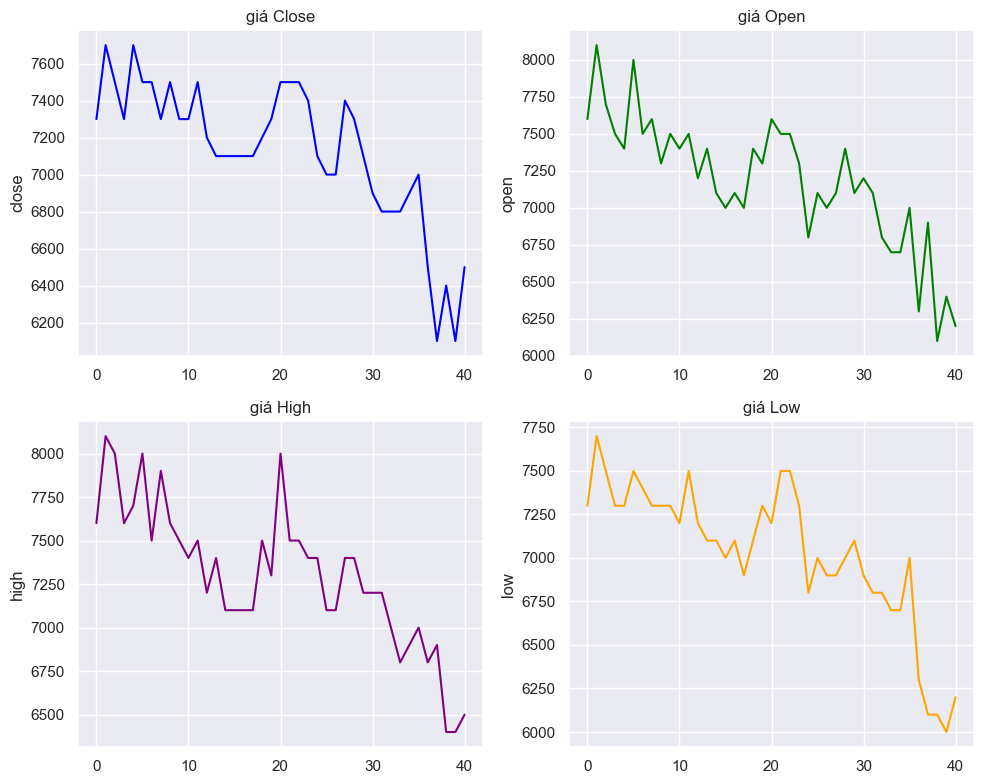

In [24]:
sns.set_theme()
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.lineplot(data=CMM_df['close'], ax=axes[0, 0], color='blue')
axes[0, 0].set_title('giá Close')

sns.lineplot(data=CMM_df['open'], ax=axes[0, 1], color='green')
axes[0, 1].set_title('giá Open')

sns.lineplot(data=CMM_df['high'], ax=axes[1, 0], color='purple')
axes[1, 0].set_title('giá High')

sns.lineplot(data=CMM_df['low'], ax=axes[1, 1], color='orange')
axes[1, 1].set_title('giá Low')

plt.tight_layout()
plt.show()


# Câu 8

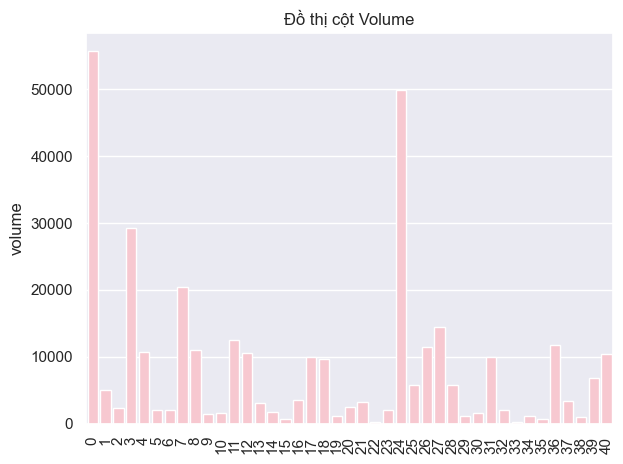

In [25]:
sns.barplot(data = CMM_df['volume'], color = 'pink')
plt.xticks(rotation = 90)
plt.title('Đồ thị cột Volume')
plt.tight_layout()
plt.show()

# Câu 9

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
X = CMM_df['volume']
X = X.values.reshape(-1, 1) if isinstance(X, pd.Series) else X

y = CMM_df['close']
y = y.values if isinstance(y, pd.Series) else y

In [28]:
model = LinearRegression()

In [29]:
model.fit(X, y)

LinearRegression()

# Câu 10

In [30]:
random_volume = np.random.randint(CMM_df.describe()['volume']['min'], CMM_df.describe()['volume']['max'], size = 10)

In [31]:
y_pred = model.predict(random_volume.reshape(-1, 1))

In [32]:
print('Dự báo giá Close mới dựa trên Volume:')
new_df = pd.DataFrame({'random volume': random_volume,'predicted close': y_pred})
new_df

Dự báo giá Close mới dựa trên Volume:


,random volume,predicted close
0,26383,7173.346586
1,31881,7187.497461
2,13556,7140.332168
3,47354,7227.322214
4,41775,7212.962859
5,2088,7110.815574
6,17610,7150.766443
7,16445,7147.767940
8,40660,7210.093047
9,24629,7168.832102
